# Predicción de `actual_partner_quoted_price`

Entrenamos dos modelos para predecir el precio total del quote del partner:
1. **Ridge** — baseline lineal con regularización L2
2. **CatBoost** — gradient boosting con soporte nativo de categóricas

## Decisiones clave

- **Target**: `actual_partner_quoted_price` (precio total). Aplicamos `log1p` porque el precio es right-skewed; MAPE se calcula en USD originales.
- **Feature explícita**: `actual_partner_quoted_quantity` — permite al modelo capturar descuentos por volumen.
- **Validación**: 5-fold CV plain (sin estratificar), `shuffle=True`, `random_state=42`.
- **Métrica**: **MAPE** sobre el precio en USD originales (no en log space).
- **SHAP**: aplicado al modelo CatBoost final entrenado sobre todo el dataset.

## Features excluidos

| Feature | Razón |
|---|---|
| `radii_id`, `product_name` | Identificadores |
| `actual_partner_quoted_price` | Es el target |
| `removed_volume_cm3` | Derivado: `stock_volume - part_volume` |
| `material_removal_pct` | Derivado: `removed_volume / stock_volume` |
| `weight_g` | Colineal con `part_volume_cm3 × densidad(material_title)` |
| `stock_volume_cm3` | Colineal con `part_volume_cm3` |
| `metadata.bounding_box_mm.{x,y,z}` | Colineales con `bbox_ratio_2/3 × part_volume_cm3` |
| `face_orientation_distribution.Z+_pct` | Colineal perfecta: `X+ + Y+ + Z+ = 1` |

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_percentage_error

from catboost import CatBoostRegressor, Pool
import shap

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

RANDOM_STATE = 42
N_FOLDS = 5

## 1. Cargar dataset

In [26]:
df = pd.read_parquet('manufacturing_quotes_clean.parquet')
print(f'Shape: {df.shape}')
print(f'\nTarget stats (actual_partner_quoted_price):')
print(df['actual_partner_quoted_price'].describe().round(2).to_string())

Shape: (288, 35)

Target stats (actual_partner_quoted_price):
count      288.00
mean       459.62
std       1844.11
min          4.81
25%         27.52
50%         86.46
75%        244.82
max      27150.28


## 2. Definir features y target

In [27]:
TARGET = 'actual_partner_quoted_price'

CATEGORICAL_FEATURES = [
    'partner_country',
    'material_title',
    'technology',
    'tolerance_tier',
    'finishing',
    'heat_treatment',
    'axis_recommendation',
]

NUMERIC_FEATURES = [
    'actual_partner_quoted_quantity',
    # Shape features dimensionless
    'aspect_ratio', 'plane_ratio', 'cyl_ratio', 'complex_ratio',
    'bbox_ratio_2', 'bbox_ratio_3',
    'face_orientation_distribution.X+_pct',
    'face_orientation_distribution.Y+_pct',
    'direction_count',
    'angled_hole_count_log',
    # Tamaño absoluto (solo un representante)
    'part_volume_cm3',
    # Conteos geométricos
    'total_holes', 'faces_qty', 'metadata.max_hole_depth_mm',
]

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

# Asegurar tipos: categóricas como string (CatBoost lo requiere)
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].astype(str).fillna('unknown')

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Drop filas con target NaN (si hubiera)
mask = y.notna()
X, y = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)

print(f'Filas: {len(X)}')
print(f'Features: {X.shape[1]} ({len(CATEGORICAL_FEATURES)} cat + {len(NUMERIC_FEATURES)} num)')
print(f'\nNaN por feature numérica:')
print(X[NUMERIC_FEATURES].isna().sum()[lambda s: s > 0].to_string() or '  (ninguno)')

Filas: 288
Features: 22 (7 cat + 15 num)

NaN por feature numérica:
bbox_ratio_2                            9
bbox_ratio_3                            9
face_orientation_distribution.X+_pct    9
face_orientation_distribution.Y+_pct    9
direction_count                         9
angled_hole_count_log                   9
metadata.max_hole_depth_mm              9


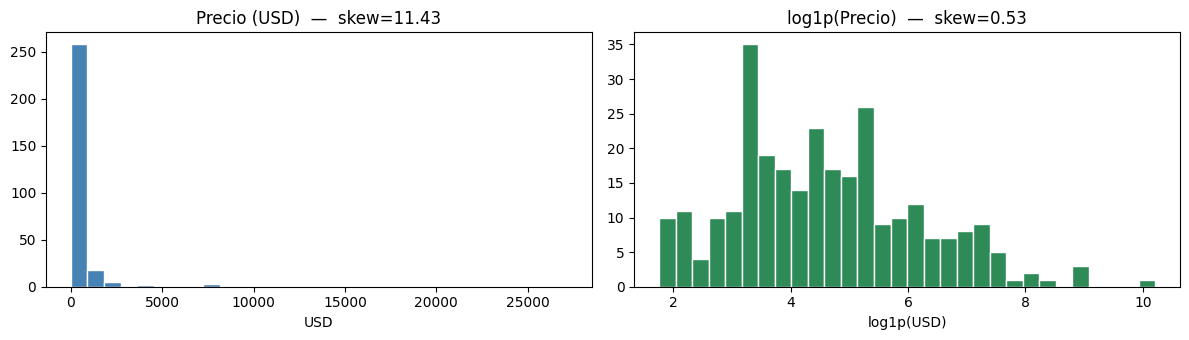

In [28]:
# Distribución del target — verificamos el skew que justifica log1p
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(y, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Precio (USD)  —  skew={y.skew():.2f}')
axes[0].set_xlabel('USD')
axes[1].hist(np.log1p(y), bins=30, color='seagreen', edgecolor='white')
axes[1].set_title(f'log1p(Precio)  —  skew={np.log1p(y).skew():.2f}')
axes[1].set_xlabel('log1p(USD)')
plt.tight_layout()
plt.show()

## 3. Ridge baseline con 5-fold CV

Pipeline:
- Numéricas → imputación mediana + estandarización
- Categóricas → imputación 'unknown' + one-hot (ignora categorías nuevas)
- Modelo: `RidgeCV` con búsqueda de α ∈ {0.01, 0.1, 1, 10, 100} dentro de cada fold
- Target: `log1p(price)`; predicciones se devuelven a USD con `expm1` antes de MAPE

In [29]:
numeric_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_FEATURES),
    ('cat', categorical_pipe, CATEGORICAL_FEATURES),
])

def build_ridge():
    return Pipeline([
        ('prep', preprocessor),
        ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])),
    ])

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

ridge_mapes = []
ridge_alphas = []
for i, (tr, te) in enumerate(kf.split(X), start=1):
    model = build_ridge()
    model.fit(X.iloc[tr], np.log1p(y.iloc[tr]))
    y_pred = np.expm1(model.predict(X.iloc[te]))
    y_pred = np.clip(y_pred, 0, None)  # no precios negativos
    mape = mean_absolute_percentage_error(y.iloc[te], y_pred) * 100
    ridge_mapes.append(mape)
    ridge_alphas.append(model.named_steps['model'].alpha_)

## 4. CatBoost con 5-fold CV

- Categóricas pasadas **nativas** (sin one-hot) vía `cat_features=`
- Maneja NaN en numéricas internamente
- Hyperparams modestos (dataset chico → evitar overfitting): `iterations=500`, `depth=5`, `learning_rate=0.05`, `l2_leaf_reg=5`
- Mismo tratamiento de target: `log1p` train → `expm1` predict

In [30]:
def build_catboost():
    return CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=5,
        l2_leaf_reg=5,
        cat_features=CATEGORICAL_FEATURES,
        random_seed=RANDOM_STATE,
        verbose=0,
    )

cb_mapes = []
for i, (tr, te) in enumerate(kf.split(X), start=1):
    model = build_catboost()
    model.fit(X.iloc[tr], np.log1p(y.iloc[tr]))
    y_pred = np.expm1(model.predict(X.iloc[te]))
    y_pred = np.clip(y_pred, 0, None)
    mape = mean_absolute_percentage_error(y.iloc[te], y_pred) * 100
    cb_mapes.append(mape)
    print(f'  Fold {i}: MAPE={mape:6.2f}%')

print(f'\nCatBoost MAPE: {np.mean(cb_mapes):.2f}% ± {np.std(cb_mapes):.2f}%')

  Fold 1: MAPE= 72.40%
  Fold 2: MAPE= 52.67%
  Fold 3: MAPE= 72.50%
  Fold 4: MAPE= 55.15%
  Fold 5: MAPE= 48.41%

CatBoost MAPE: 60.23% ± 10.21%


## 5. Comparación

In [31]:
results = pd.DataFrame({
    'Ridge':    [*ridge_mapes, np.mean(ridge_mapes), np.std(ridge_mapes)],
    'CatBoost': [*cb_mapes,    np.mean(cb_mapes),    np.std(cb_mapes)],
}, index=[f'Fold {i}' for i in range(1, N_FOLDS + 1)] + ['Mean', 'Std']).round(2)
results

,Ridge,CatBoost
Fold 1,99.44,72.40
Fold 2,83.76,52.67
Fold 3,71.48,72.50
Fold 4,86.40,55.15
Fold 5,73.99,48.41
Mean,83.01,60.23
Std,9.96,10.21


## 6. Modelo final + SHAP

Reentrenamos CatBoost sobre **todo el dataset** y generamos explicaciones SHAP.

**Nota**: el modelo predice `log1p(price)`, por lo que los valores SHAP están en escala log. Contribuciones positivas empujan el precio hacia arriba, negativas hacia abajo.

In [32]:
final_model = build_catboost()
final_model.fit(X, np.log1p(y))

y_pred_full = np.clip(np.expm1(final_model.predict(X)), 0, None)
train_mape = mean_absolute_percentage_error(y, y_pred_full) * 100
print(f'MAPE en train (optimista, solo referencia): {train_mape:.2f}%')

MAPE en train (optimista, solo referencia): 32.96%


In [33]:
pool = Pool(X, cat_features=CATEGORICAL_FEATURES)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(pool)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Base value (log-price esperado): {explainer.expected_value:.3f}')

SHAP values shape: (288, 22)
Base value (log-price esperado): 4.599


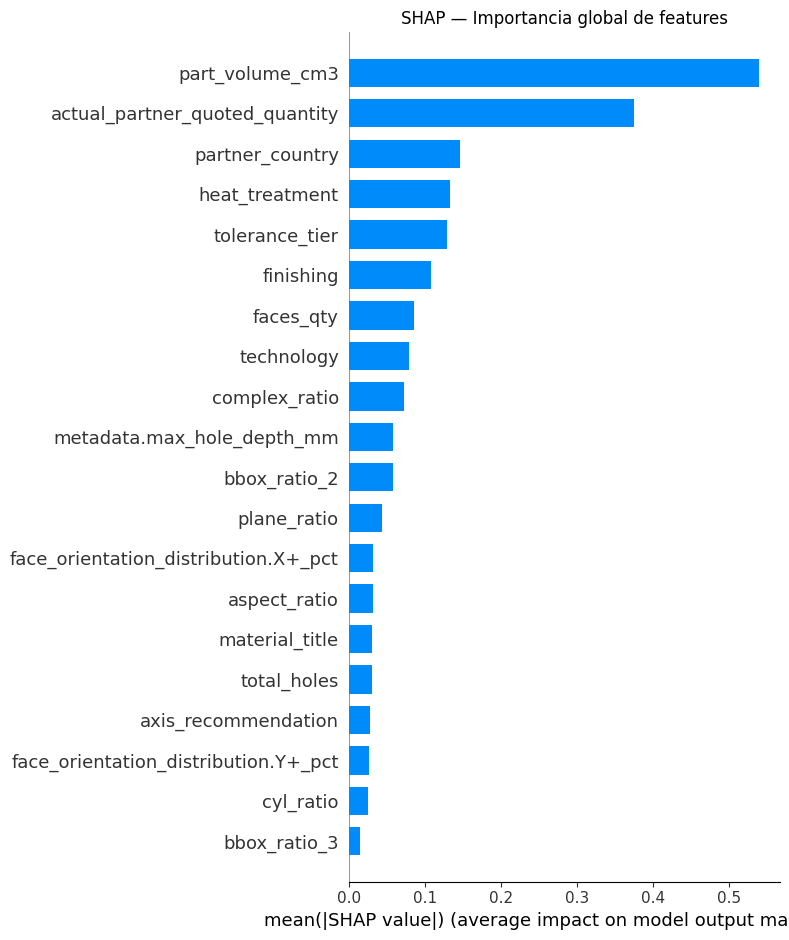

In [34]:
# Importancia global: media del |SHAP value| por feature
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('SHAP — Importancia global de features')
plt.tight_layout()
plt.show()

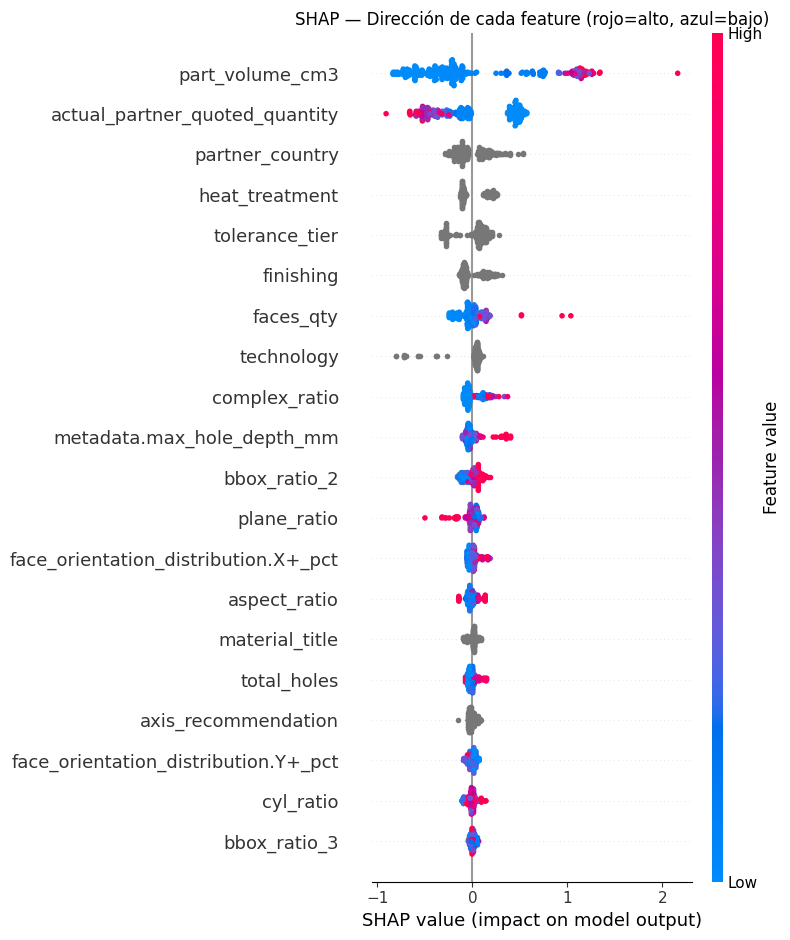

In [35]:
# Summary plot con dirección: cada punto es una pieza, color=valor del feature
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP — Dirección de cada feature (rojo=alto, azul=bajo)')
plt.tight_layout()
plt.show()

Pieza más cara — index 93:
  product_name: Assembly_QM-00794
  precio real:     $27,150.28
  precio predicho: $21,434.48



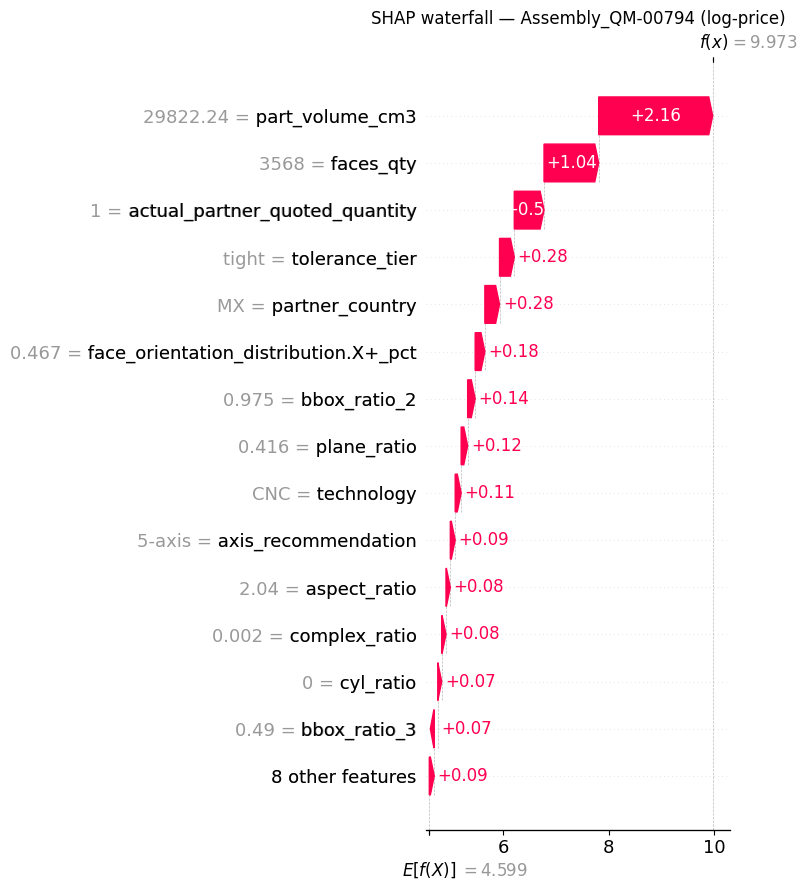

In [36]:
# Explicación individual: pieza más cara del dataset
idx = y.idxmax()
print(f'Pieza más cara — index {idx}:')
print(f'  product_name: {df.loc[idx, "product_name"]}')
print(f'  precio real:     ${y.iloc[idx]:,.2f}')
print(f'  precio predicho: ${y_pred_full[idx]:,.2f}')
print()

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx].values,
        feature_names=X.columns.tolist(),
    ),
    max_display=15,
    show=False,
)
plt.title(f'SHAP waterfall — {df.loc[idx, "product_name"]} (log-price)')
plt.tight_layout()
plt.show()